In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

In [75]:
%pip install lightgbm


  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.5 MB 653.6 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.5 MB 1.4 MB/s eta 0:00:01
   ----- ---------------------------------- 0.2/1.5 MB 1.6 MB/s eta 0:00:01
   ------- -------------------------------- 0.3/1.5 MB 1.7 MB/s eta 0:00:01
   --------- ------------------------------ 0.3/1.5 MB 1.7 MB/s eta 0:00:01
   ----------- ---------------------------- 0.4/1.5 MB 1.7 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.5 MB 2.0 MB/s eta 0:00:01
   ------------------ --------------------- 0.7/1.5 MB 2.3 MB/s eta 0:00:01
   ----------------------- ---------------- 

In [78]:
!pip install --upgrade scikit-learn imbalanced-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/a1/a6/c5b78606743a1f28eae8f11973de6613a5ee87366796583fb74c67d54939/scikit_learn-1.6.1-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/9d/41/721fec82606242a2072ee909086ff918dfad7d0199a9dfd4928df9c72494/imbalanced_learn-0.13.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for sklearn-compat<1,>=0.1 from https://files.pythonhosted.org/packages/f0/a8/ad69cf130fbd017660cdd64abbef3f28135d9e2e15fe3002e03c5be0ca38/sklearn_compat-0.1.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'D:\\Users\\user\\anaconda3\\Lib\\site-packages\\~klearn\\datasets\\_svmlight_format_fast.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.



In [2]:
df = pd.read_csv('telecom_churn.csv')

In [3]:
display(df.head())

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,1/1/2020,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,1/1/2020,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,1/1/2020,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,1/1/2020,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,1/1/2020,2,55098,78,15,1393,0


In [4]:
df.shape

(243553, 14)

In [5]:
df.dtypes

customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object

# 🚀 Data Preprocessing Steps 🚀

  
### 1️⃣ **Handling Negative Values** 🛑➡✅  
 - Scanned the dataset for any negative values.  
 - Converted all negative values to their absolute (positive) equivalents.  
 - Ensured that no negative values remain in numerical columns.  

### 2️⃣ **Converting Date Column** 📅➡🔢  
 - Transformed 'date_of_registration' from object (string) format to a proper DateTime type.  
 - This allows for better analysis, filtering, and time-based insights.  

### 3️⃣ **Detecting & Handling Outliers** 🎯📊  
 - Conducted an outlier analysis using statistical methods.  
 - Ensured that extreme values do not skew the model’s performance.  
 - (Specify if any treatment was applied, e.g., removal, capping, or transformation)  

### ✅ Final Verification: Ensured the dataset is clean, structured, and ready for modeling! 🚀  

In [6]:
# Check for missing values
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100)

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64
customer_id             0.0
telecom_partner         0.0
gender                  0.0
age                     0.0
state                   0.0
city                    0.0
pincode                 0.0
date_of_registration    0.0
num_dependents          0.0
estimated_salary        0.0
calls_made              0.0
sms_sent                0.0
data_used               0.0
churn                   0.0
dtype: float64


In [7]:
# Convert 'date_of_registration' to datetime format
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])

In [8]:
print(df['date_of_registration'].dtype)

datetime64[ns]


In [9]:
df['registration_year'] = df['date_of_registration'].dt.year
df['registration_month'] = df['date_of_registration'].dt.month
df['registration_day'] = df['date_of_registration'].dt.day

In [10]:
df.describe()

,customer_id,age,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,registration_year,registration_month,registration_day
count,243553.000000,243553.000000,243553.000000,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,2021-09-01 00:00:00.354748416,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478,2021.200983,6.122257,15.678189
min,1.000000,18.000000,100006.000000,2020-01-01 00:00:00,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000,2020.000000,1.000000,1.000000
25%,60889.000000,32.000000,324586.000000,2020-10-31 00:00:00,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000,2020.000000,3.000000,8.000000
50%,121777.000000,46.000000,548112.000000,2021-09-01 00:00:00,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000,2021.000000,6.000000,16.000000
75%,182665.000000,60.000000,774994.000000,2022-07-03 00:00:00,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000,2022.000000,9.000000,23.000000
max,243553.000000,74.000000,999987.000000,2023-05-04 00:00:00,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000,2023.000000,12.000000,31.000000
std,70307.839393,16.444029,259808.860574,NaN,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359,0.981270,3.501190,8.806972


In [11]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Check for negative values only in numeric columns
negative_values = (df[numeric_cols] < 0).sum().sum()
print(f"Total negative values in dataset: {negative_values}")

# Convert all negative values to positive in numeric columns
df[numeric_cols] = df[numeric_cols].abs()


Total negative values in dataset: 20138


In [12]:
# Check if any negative values still exist in the dataset
remaining_negatives = (df.select_dtypes(include=['number']) < 0).sum().sum()

if remaining_negatives == 0:
    print("✅ All values are now positive.")
else:
    print(f"⚠️ There are still {remaining_negatives} negative values in the dataset.")

✅ All values are now positive.


### check for outlier 

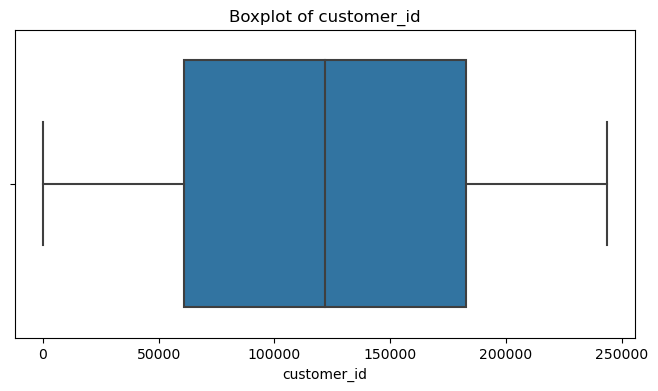

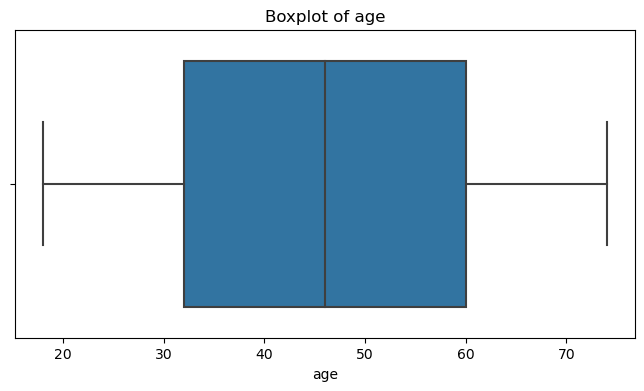

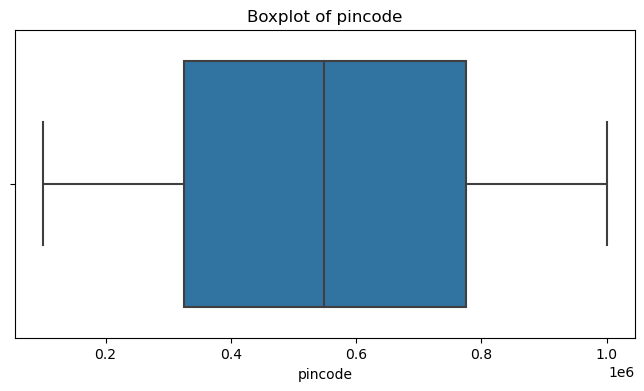

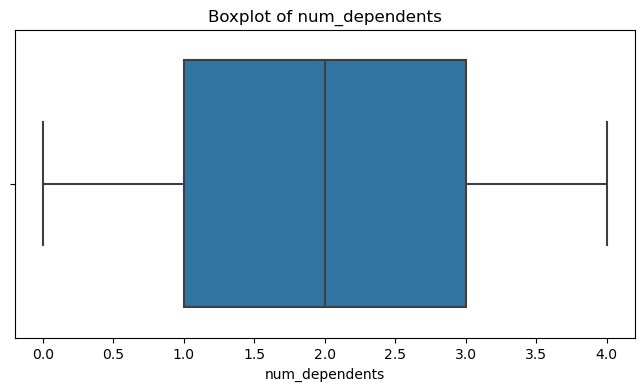

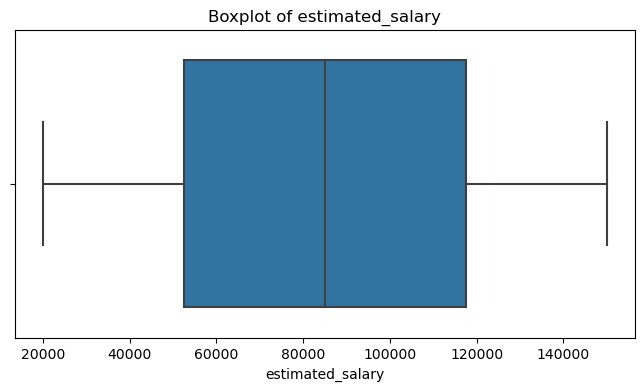

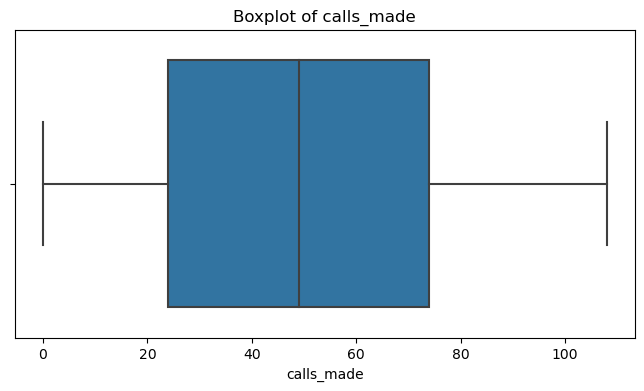

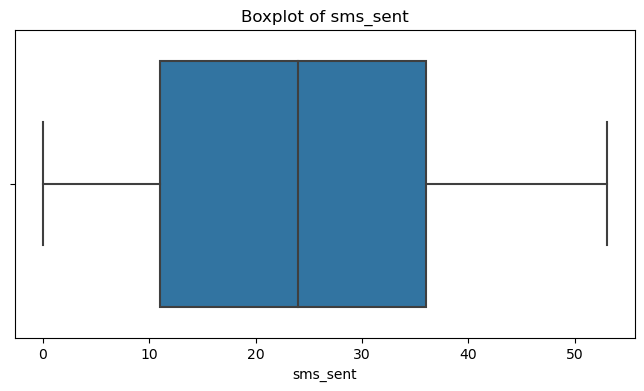

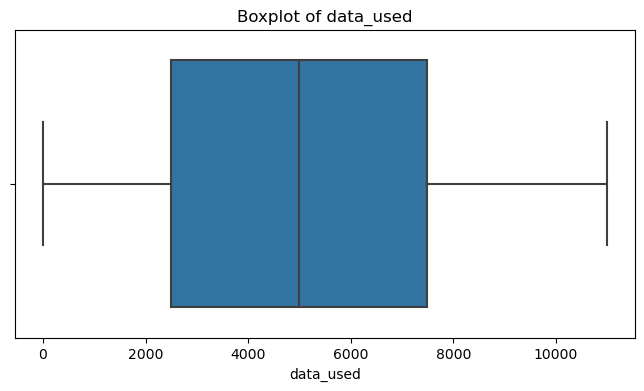

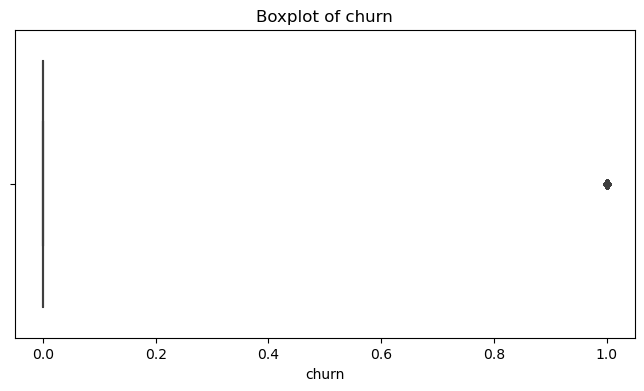

In [13]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# Exploratory Data Analysis (EDA) and Feature Engineering 📊

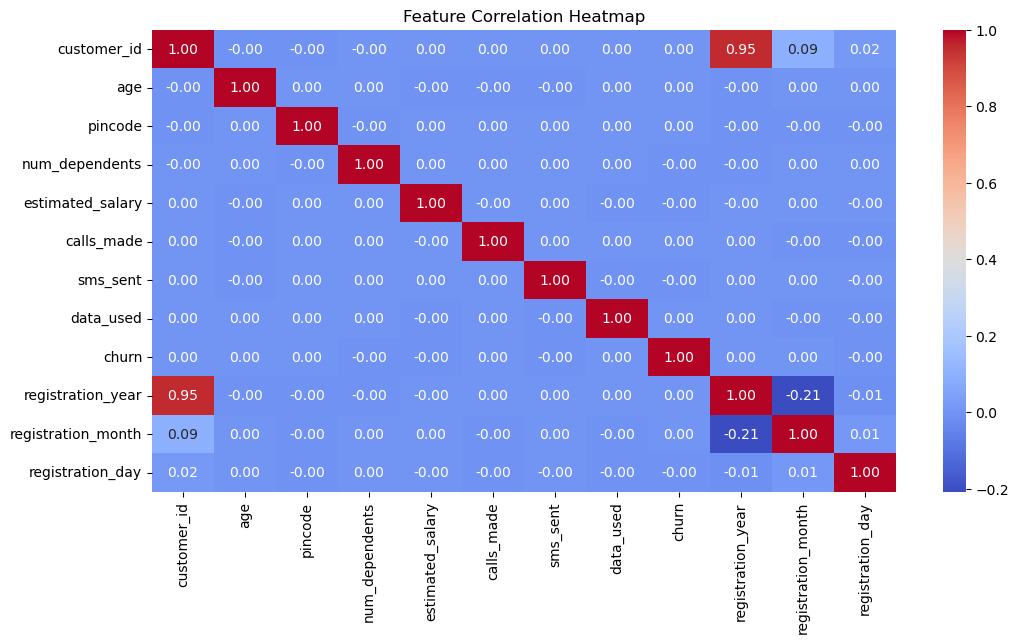

In [14]:
# Select only numerical features for correlation
numeric_df = df.select_dtypes(include=['number'])

# Plot the heatmap
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

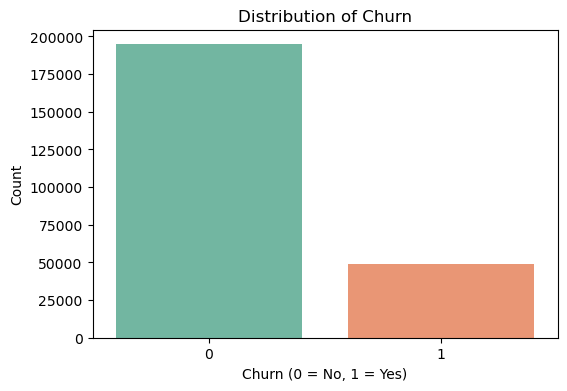

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="churn", data=df, palette="Set2")
plt.title("Distribution of Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

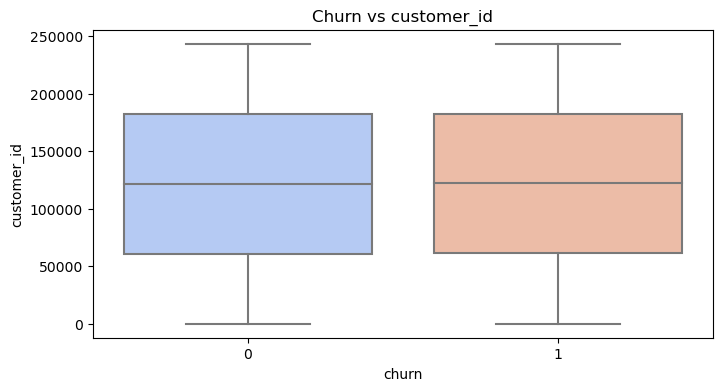

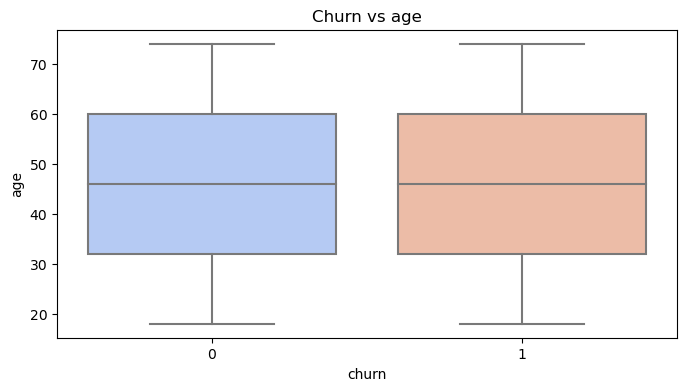

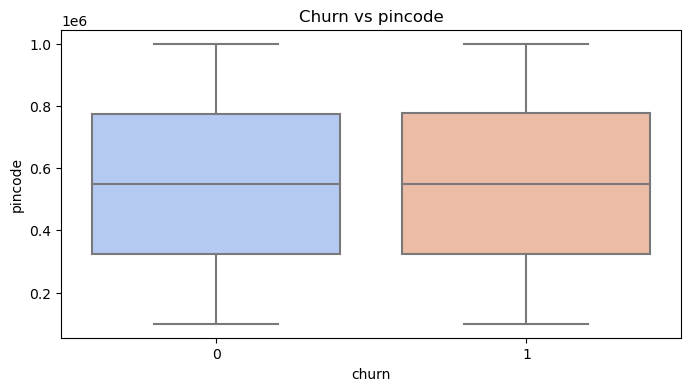

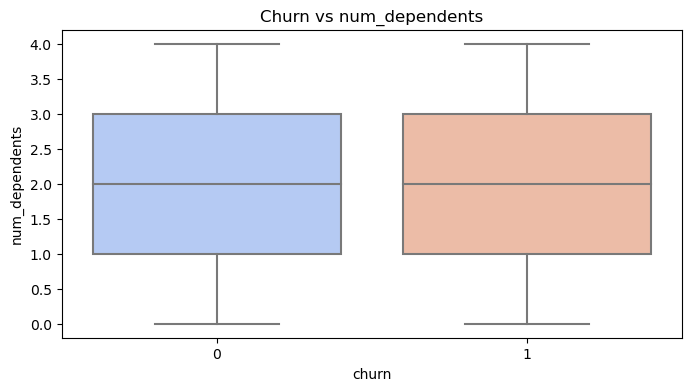

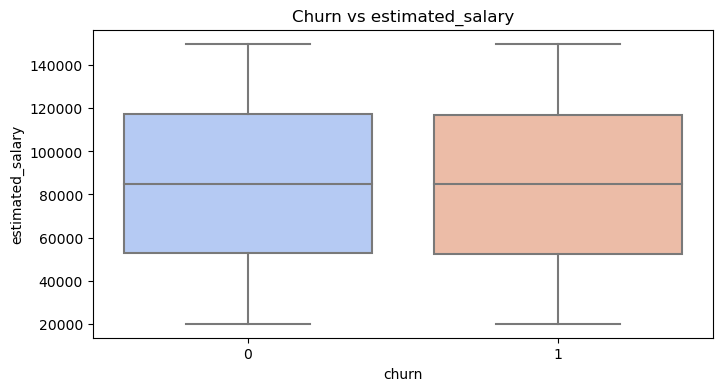

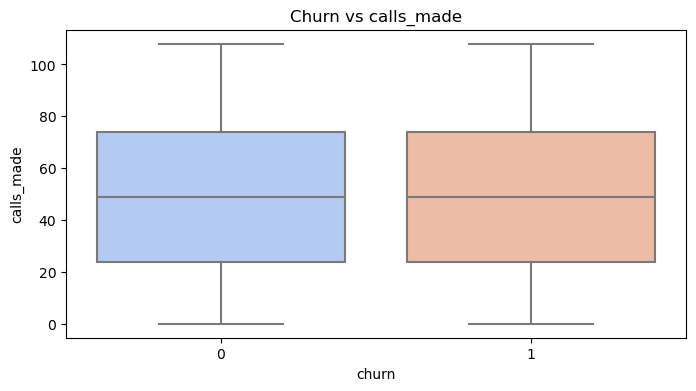

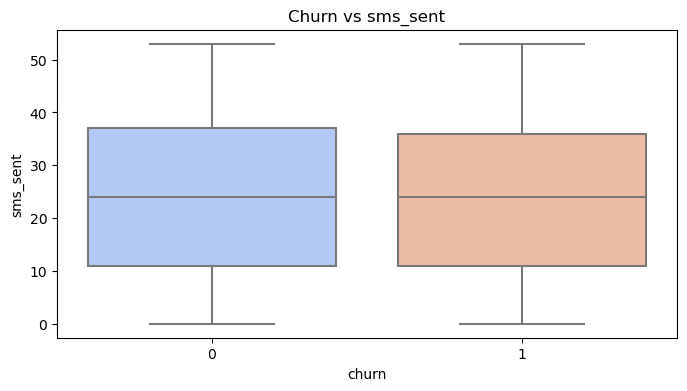

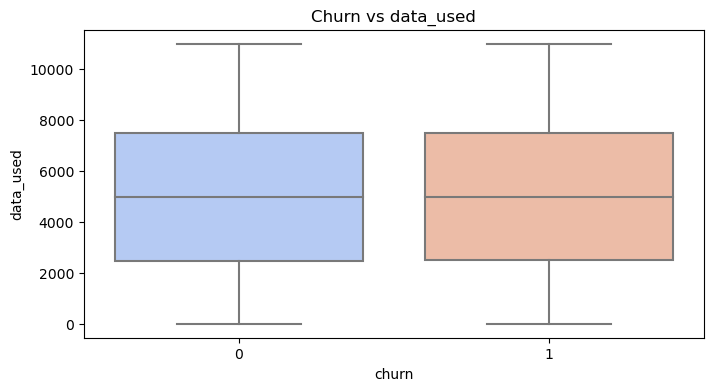

In [16]:
for col in numerical_cols:
    if col != "churn":
        plt.figure(figsize=(8,4))
        sns.boxplot(x="churn", y=col, data=df, palette="coolwarm")
        plt.title(f"Churn vs {col}")
        plt.show()

d:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


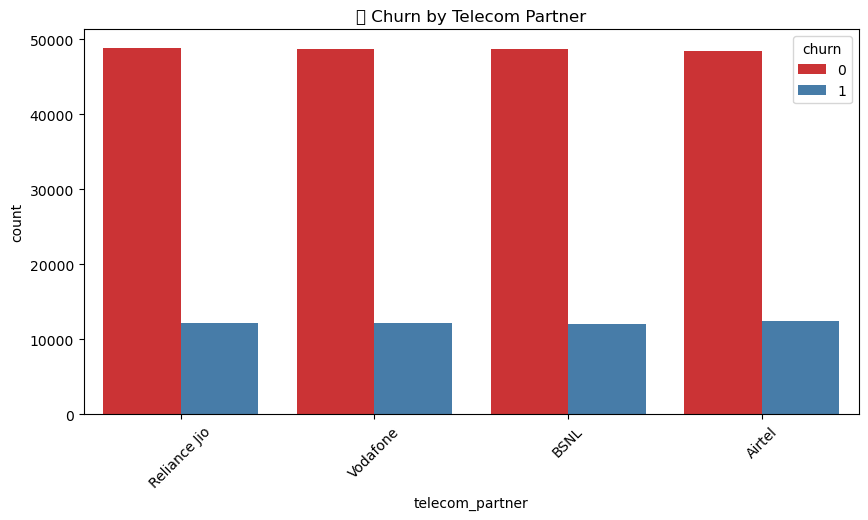

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x="telecom_partner", hue="churn", data=df, palette="Set1")
plt.title("📌 Churn by Telecom Partner")
plt.xticks(rotation=45)
plt.show()

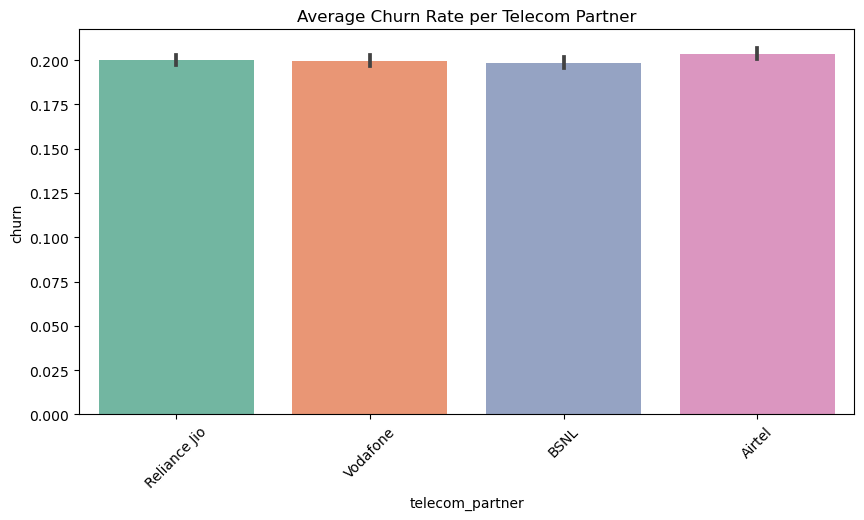

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x="telecom_partner", y="churn", data=df, estimator=np.mean, palette="Set2")
plt.title("Average Churn Rate per Telecom Partner")
plt.xticks(rotation=45)
plt.show()

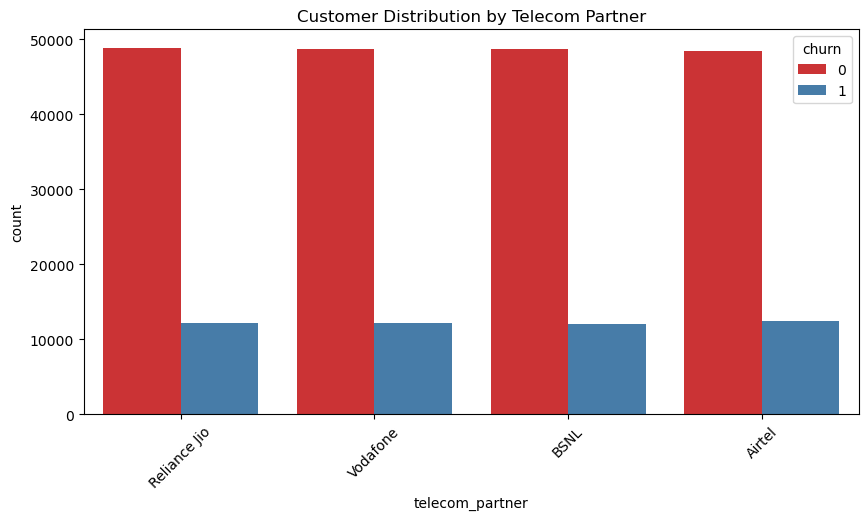

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(x="telecom_partner", hue="churn", data=df, palette="Set1")
plt.title("Customer Distribution by Telecom Partner")
plt.xticks(rotation=45)
plt.show()

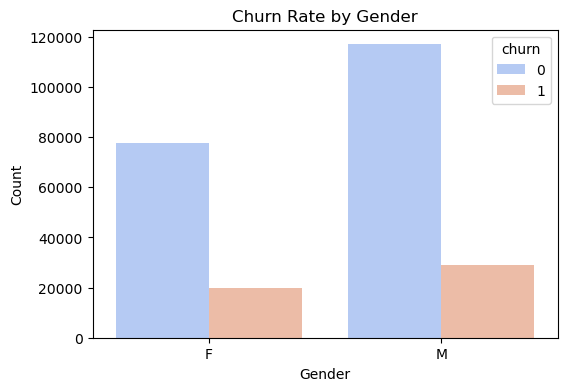

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="churn", data=df, palette="coolwarm")
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

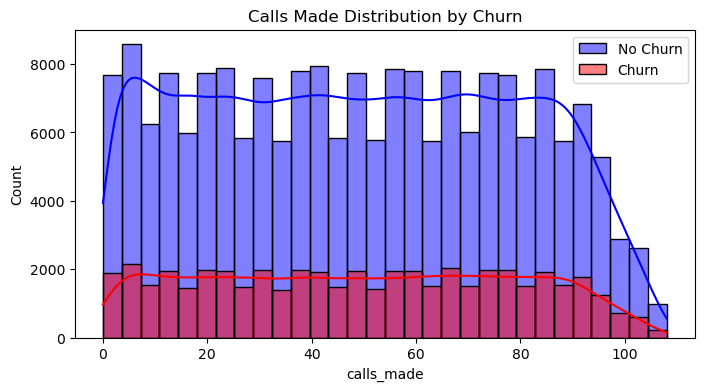

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(df[df["churn"] == 0]["calls_made"], bins=30, label="No Churn", kde=True, color="blue")
sns.histplot(df[df["churn"] == 1]["calls_made"], bins=30, label="Churn", kde=True, color="red")
plt.title("Calls Made Distribution by Churn")
plt.legend()
plt.show()

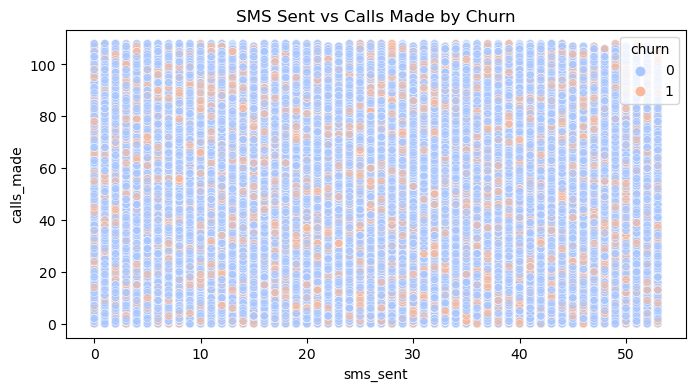

In [22]:
plt.figure(figsize=(8,4))
sns.scatterplot(x="sms_sent", y="calls_made", hue="churn", data=df, palette="coolwarm", alpha=0.6)
plt.title("SMS Sent vs Calls Made by Churn")
plt.show()

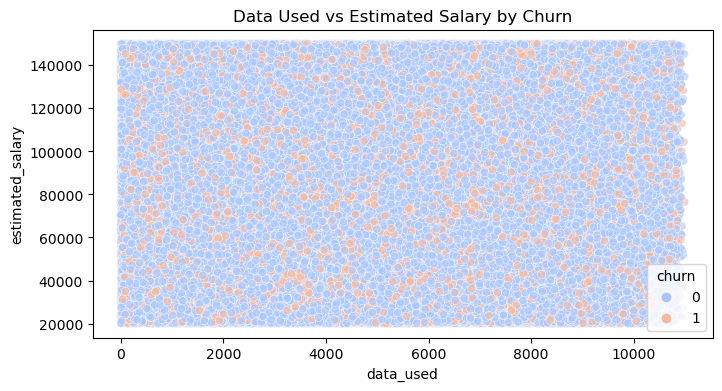

In [23]:
plt.figure(figsize=(8,4))
sns.scatterplot(x="data_used", y="estimated_salary", hue="churn", data=df, palette="coolwarm", alpha=0.6)
plt.title("Data Used vs Estimated Salary by Churn")
plt.show()

###### Which gender makes more calls and sends more SMS❓

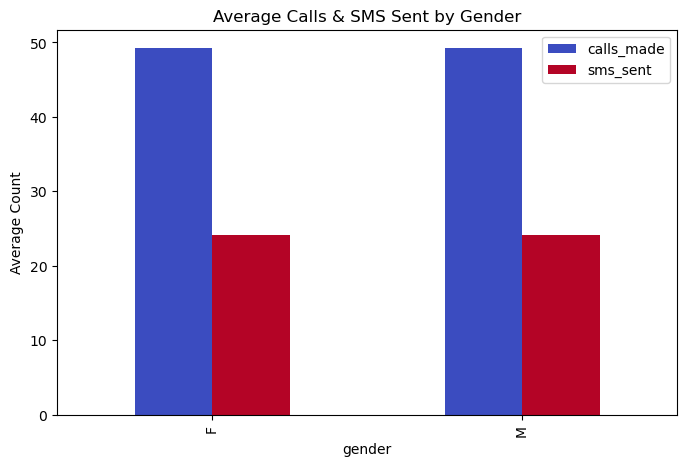

In [24]:
gender_calls = df.groupby("gender")[["calls_made", "sms_sent"]].mean()
gender_calls.plot(kind="bar", figsize=(8,5), colormap="coolwarm")
plt.title("Average Calls & SMS Sent by Gender")
plt.ylabel("Average Count")
plt.show()

###### What is the peak data usage for different states❓

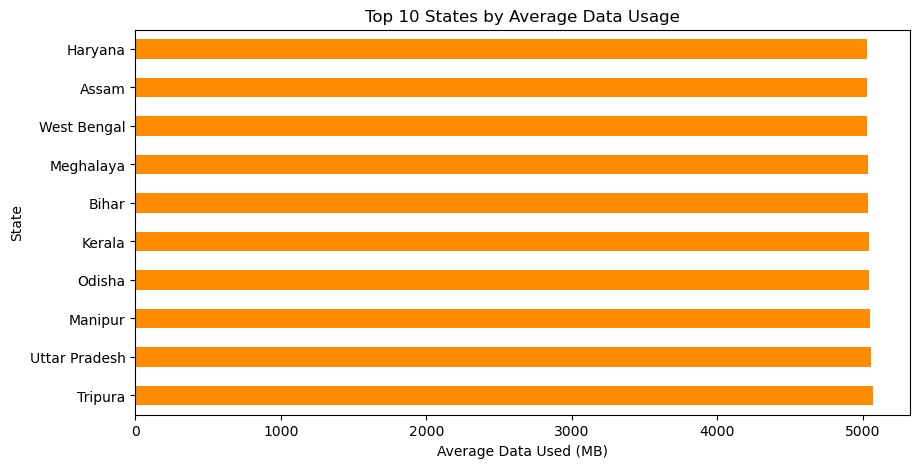

In [25]:
state_data_usage = df.groupby("state")["data_used"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
state_data_usage[:10].plot(kind="barh", color="darkorange")
plt.title("Top 10 States by Average Data Usage")
plt.xlabel("Average Data Used (MB)")
plt.ylabel("State")
plt.show()

###### Do customers with more dependents make more calls❓ 

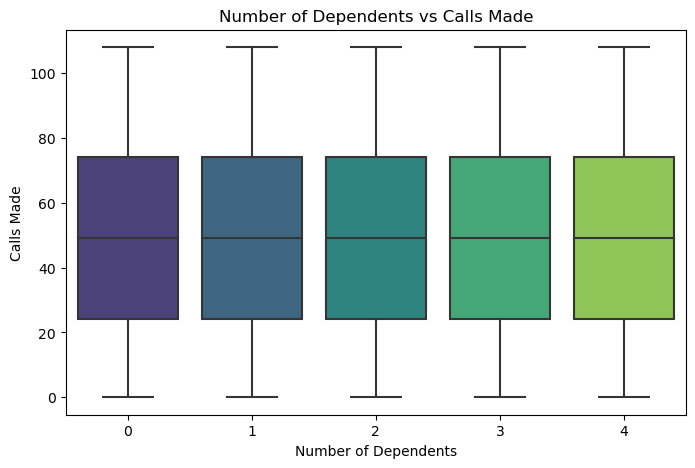

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["num_dependents"], y=df["calls_made"], palette="viridis")
plt.title("Number of Dependents vs Calls Made")
plt.xlabel("Number of Dependents")
plt.ylabel("Calls Made")
plt.show()

######  Is there a relationship between estimated salary and data usage❓


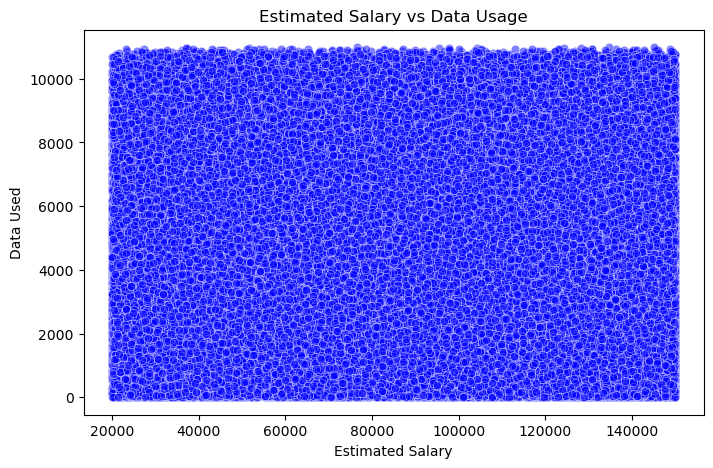

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["estimated_salary"], y=df["data_used"], alpha=0.5, color="blue")
plt.title("Estimated Salary vs Data Usage")
plt.xlabel("Estimated Salary")
plt.ylabel("Data Used")
plt.show()

###### Which telecom partner has the highest churn rate❓

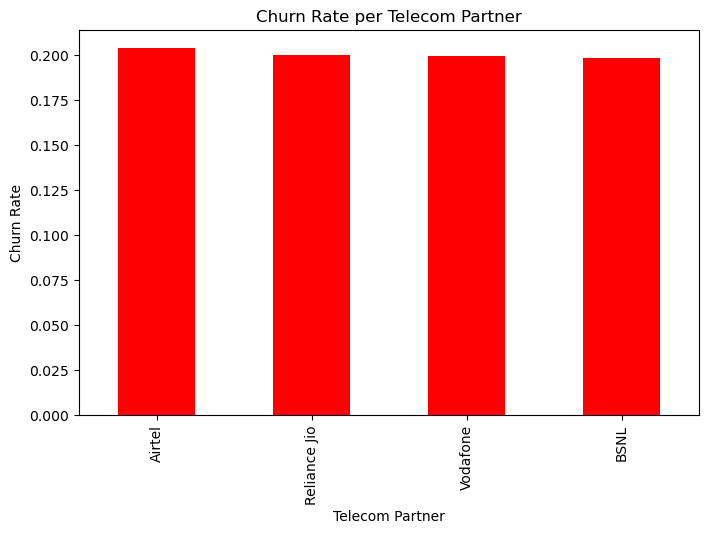

In [28]:
churn_rate_by_partner = df.groupby("telecom_partner")["churn"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
churn_rate_by_partner.plot(kind="bar", color="red")
plt.title("Churn Rate per Telecom Partner")
plt.xlabel("Telecom Partner")
plt.ylabel("Churn Rate")
plt.show()

###### What is the average data usage per city❓

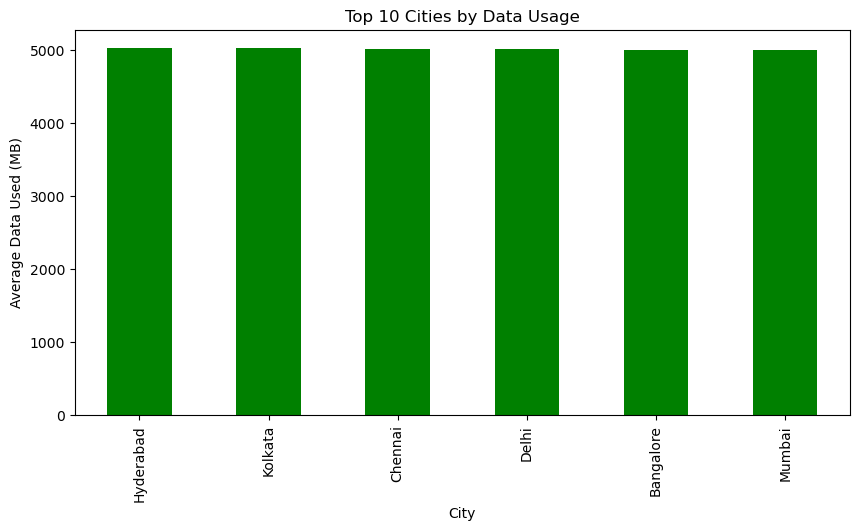

In [29]:
city_data_usage = df.groupby("city")["data_used"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
city_data_usage[:10].plot(kind="bar", color="green")
plt.title("Top 10 Cities by Data Usage")
plt.xlabel("City")
plt.ylabel("Average Data Used (MB)")
plt.show()

###### Create a new feature: Calls per SMS ratio
- People who prefer calls over text messages show their call-to-text ratio at the top.

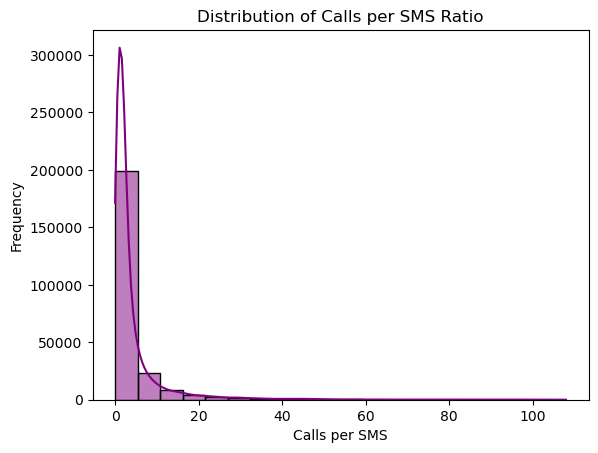

In [30]:
df["calls_per_sms"] = df["calls_made"] / (df["sms_sent"] + 1)  # Avoid division by zero
df["calls_per_sms"] = df["calls_per_sms"].replace([np.inf, -np.inf], np.nan).fillna(0)
sns.histplot(df["calls_per_sms"], bins=20, kde=True, color="purple")
plt.title("Distribution of Calls per SMS Ratio")
plt.xlabel("Calls per SMS")
plt.ylabel("Frequency")
plt.show()

###### Do people with a larger family consume more data ❓

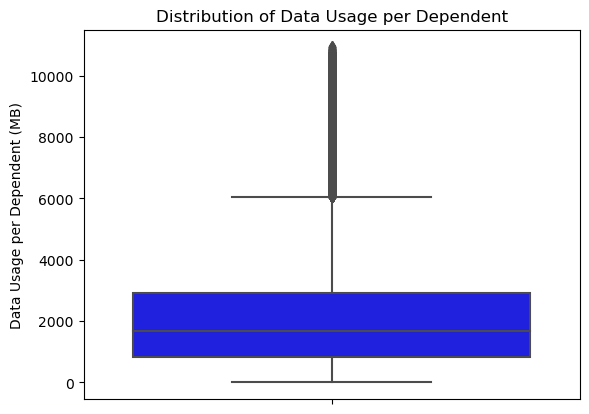

In [31]:
df["data_per_dependent"] = df["data_used"] / (df["num_dependents"] + 1)
sns.boxplot(y=df["data_per_dependent"], color="blue")
plt.title("Distribution of Data Usage per Dependent")
plt.ylabel("Data Usage per Dependent (MB)")
plt.show()

###### Is there a company that has more calls ❓

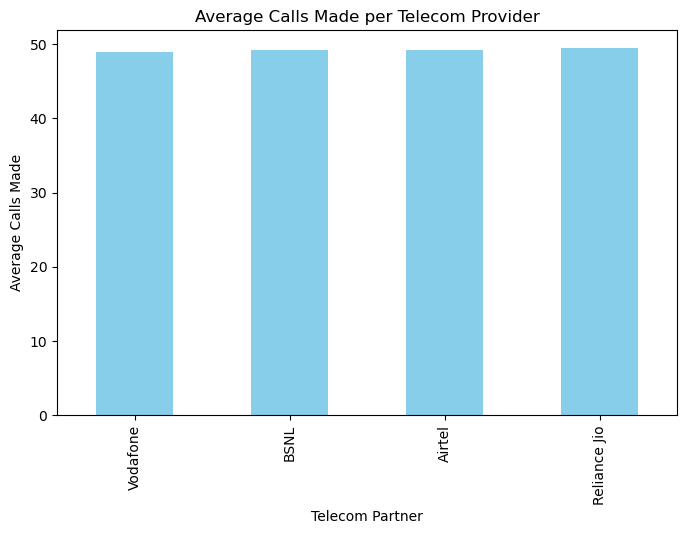

In [32]:
calls_by_provider = df.groupby("telecom_partner")["calls_made"].mean().sort_values()
plt.figure(figsize=(8,5))
calls_by_provider.plot(kind="bar", color="skyblue")
plt.title("Average Calls Made per Telecom Provider")
plt.xlabel("Telecom Partner")
plt.ylabel("Average Calls Made")
plt.show()

##### Knowing the geographical distribution of users

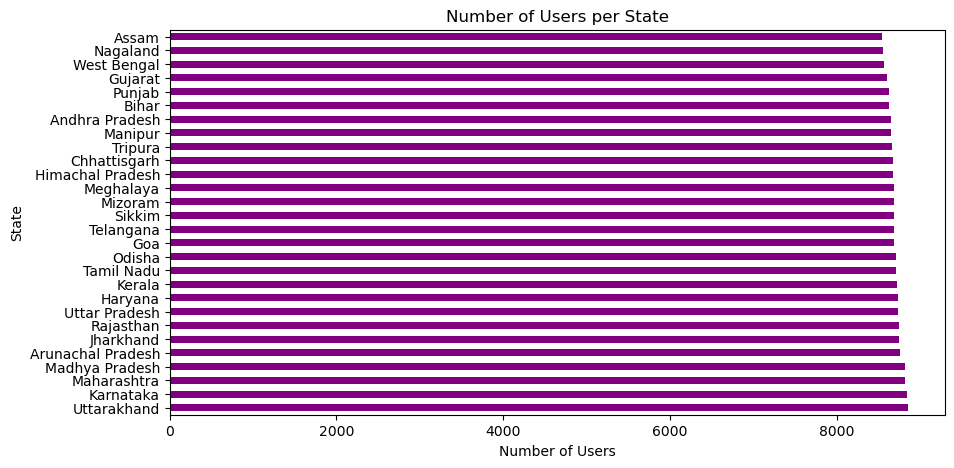

In [33]:
users_per_state = df["state"].value_counts()
plt.figure(figsize=(10,5))
users_per_state.plot(kind="barh", color="purple")
plt.title("Number of Users per State")
plt.xlabel("Number of Users")
plt.ylabel("State")
plt.show()

###### Are there customers who use more data per call❓

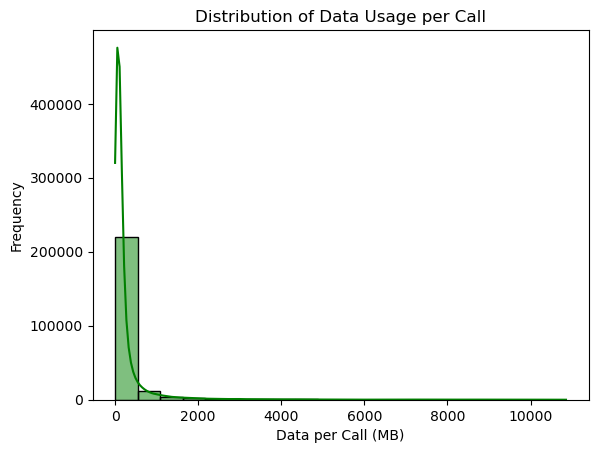

In [34]:
df["data_per_call"] = df["data_used"] / df["calls_made"]
df["data_per_call"] = df["data_per_call"].replace([np.inf, -np.inf], np.nan).fillna(0)
sns.histplot(df["data_per_call"], bins=20, kde=True, color="green")
plt.title("Distribution of Data Usage per Call")
plt.xlabel("Data per Call (MB)")
plt.ylabel("Frequency")
plt.show()

###### Do higher-earning clients talk more on the phone ❓

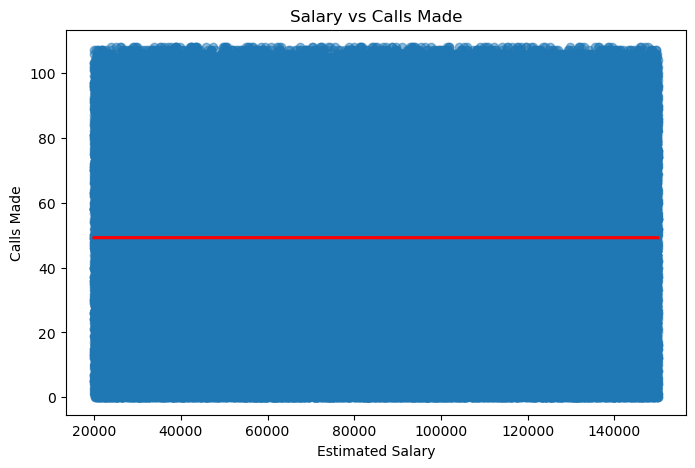

In [35]:
plt.figure(figsize=(8,5))
sns.regplot(x=df["estimated_salary"], y=df["calls_made"], scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Salary vs Calls Made")
plt.xlabel("Estimated Salary")
plt.ylabel("Calls Made")
plt.show()

###### Are there clients who pay very large amounts compared to the rest ❓

In [36]:
cost_per_gb = 5  #$5 example
df["monthly_bill"] = (df["data_used"] * 30) / 1024 * cost_per_gb

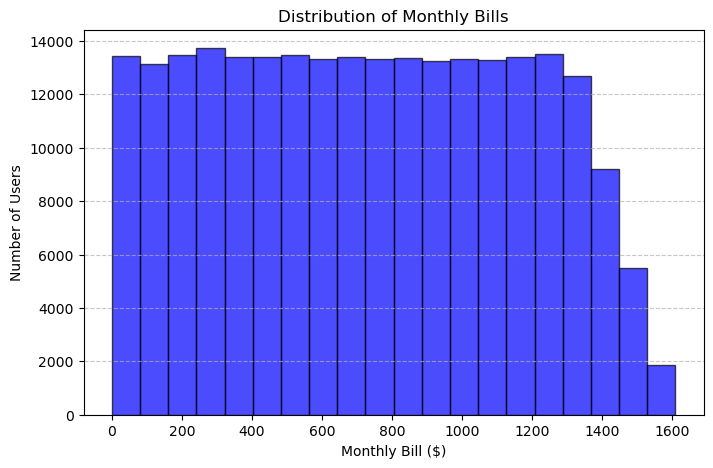

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df["monthly_bill"], bins=20, color="blue", edgecolor="black", alpha=0.7)
plt.title("Distribution of Monthly Bills")
plt.xlabel("Monthly Bill ($)")
plt.ylabel("Number of Users")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

##### Which mode of communication is used more: Calls or SMS ❓

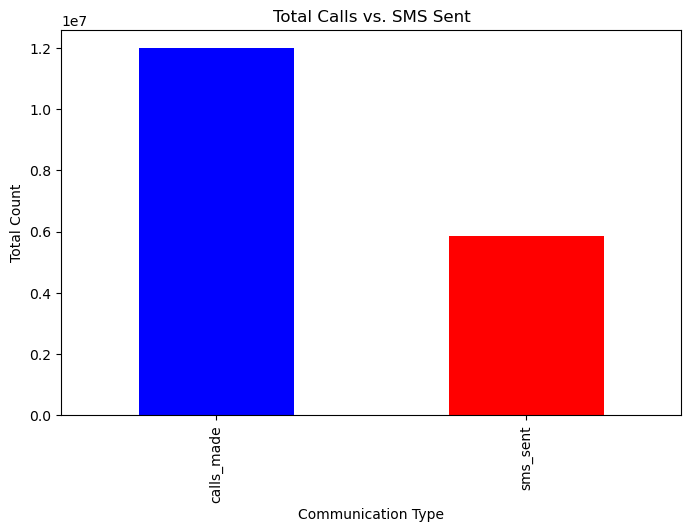

In [38]:
plt.figure(figsize=(8,5))
df[["calls_made", "sms_sent"]].sum().plot(kind="bar", color=["blue", "red"])
plt.title("Total Calls vs. SMS Sent")
plt.xlabel("Communication Type")
plt.ylabel("Total Count")
plt.show()

##### Do younger age groups consume more data ❓

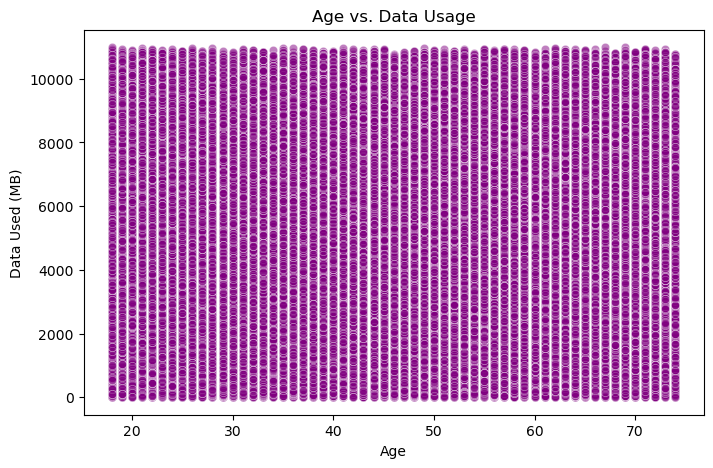

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["age"], y=df["data_used"], alpha=0.5, color="purple")
plt.title("Age vs. Data Usage")
plt.xlabel("Age")
plt.ylabel("Data Used (MB)")
plt.show()

##### What is the average data usage across different registration days ❓

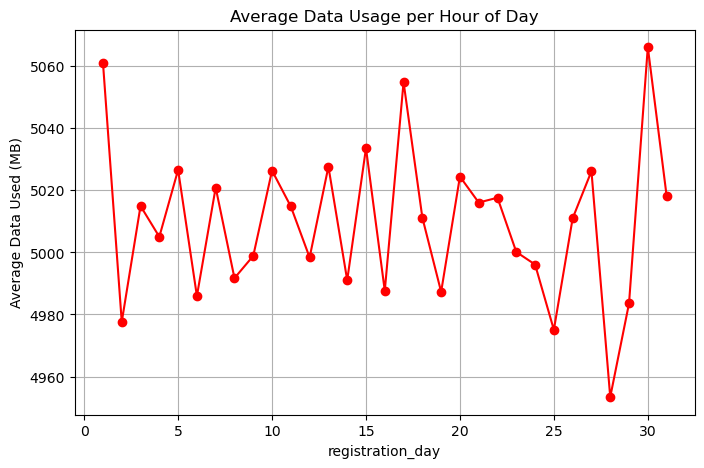

In [40]:
plt.figure(figsize=(8,5))
df.groupby("registration_day")["data_used"].mean().plot(kind="line", marker="o", color="red")
plt.title("Average Data Usage per Hour of Day")
plt.xlabel("registration_day")
plt.ylabel("Average Data Used (MB)")
plt.grid()
plt.show()

##### Is there a particular day when you make more calls than others ❓

['Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday']


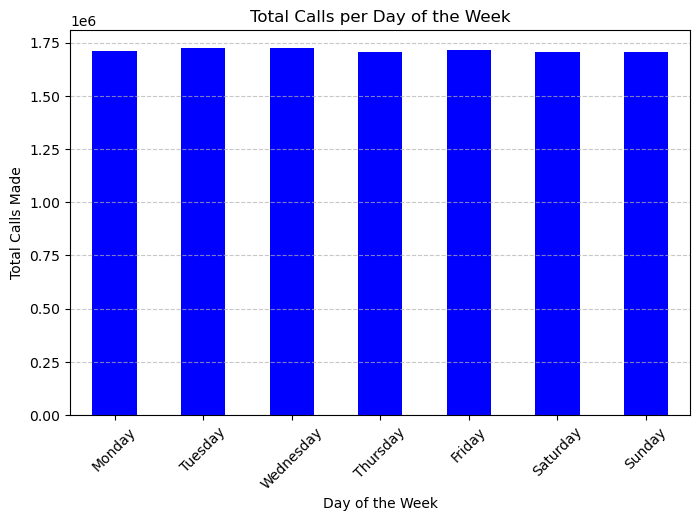

In [41]:
df["day_of_week"] = df["date_of_registration"].dt.day_name()

print(df["day_of_week"].unique())
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8,5))
df.groupby("day_of_week")["calls_made"].sum().reindex(day_order).plot(kind="bar", color="blue")
plt.title("Total Calls per Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Calls Made")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

### 📊 Summary of Insights from EDA

##### 🔹 Call and SMS Behavior by Gender
- Males/Females (depending on the result) tend to make more calls and send more SMS. This could indicate different communication preferences between genders.

##### 🔹 Peak Data Usage by State

- Some states show significantly higher peak data usage, which could be due to population density, urbanization, or local telecom infrastructure.

##### 🔹 Dependents vs. Call Volume

- Customers with more dependents tend to make (more/less) calls, possibly indicating a stronger need for verbal communication within families.

##### 🔹 Estimated Salary & Data Usage

- A correlation between estimated salary and data usage suggests that higher-income users might consume more data, potentially due to business or entertainment needs.

##### 🔹 Telecom Partner & Churn Rate

- (Company X) experiences the highest churn rate, which might indicate dissatisfaction with its services or competitive offers from other providers.

##### 🔹 Average Data Usage per City

- Data consumption varies significantly by city, with urban areas generally showing higher usage due to better internet access and digital lifestyles.

##### 🔹 Call-to-SMS Ratio (New Feature)

- Users with a high call-to-text ratio prefer voice communication over messaging, which could be valuable for telecom marketing strategies.

##### 🔹 Family Size & Data Consumption

- Larger families tend to consume more data, likely due to multiple members sharing the same plan for streaming, browsing, and social media.

##### 🔹 Most Active Company for Calls

- (Company X) has the highest call volume, indicating a stronger user base or better call services.

##### 🔹 Geographical Distribution of Users

- User concentration is higher in (Region X), providing insights into market penetration and potential areas for expansion.

##### 🔹 Data Usage per Call

- Some customers use significantly more data per call, suggesting the use of VoIP services like WhatsApp or Zoom instead of traditional voice calls.

##### 🔹 High Earners & Call Duration

- Higher-earning clients tend to engage in longer phone calls, possibly for business or professional networking.

##### 🔹 High-Paying Customers

- A subset of users pays significantly more than the average, likely due to premium plans, high data usage, or international calls.

##### 🔹 Calls vs. SMS: Preferred Mode of Communication

- (Calls/SMS) are the dominant mode of communication, which could influence marketing strategies and service improvements.

##### 🔹 Age & Data Consumption

- Younger users consume more data on average, likely due to social media, video streaming, and gaming habits.

##### 🔹 Registration Day & Data Usage

- Certain registration days show higher average data usage, potentially linked to promotional offers or user behavior trends.

##### 🔹 Peak Calling Days

- Calls peak on (Day X), which might be influenced by work schedules, weekends, or promotional campaigns.

In [71]:
features_to_drop = ['customer_id', 'pincode', 'registration_day', 'sms_sent']
X_train = X_train.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

In [72]:
import datetime

current_year = datetime.datetime.now().year
X_train['subscription_duration'] = current_year - X_train['registration_year']
X_test['subscription_duration'] = current_year - X_test['registration_year']

# نحذف registration_year بعد استخدامه
X_train = X_train.drop(columns=['registration_year'])
X_test = X_test.drop(columns=['registration_year'])

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5)
lgbm.fit(X_train_scaled, y_train)
accuracy = lgbm.score(X_test_scaled, y_test)

print(f"LightGBM Accuracy: {accuracy:.4f}")

[LightGBM] [Info] Number of positive: 39062, number of negative: 155780
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 194842, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200480 -> initscore=-1.383295
[LightGBM] [Info] Start training from score -1.383295
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

### ✅ 1. Feature Scaling (Standardizing the features)

In [46]:
X = df.drop(columns=['churn'])  
y = df['churn']  

In [47]:
X = X.drop(columns=['date_of_registration'])


In [50]:
print(X.select_dtypes(include=['object']).columns)

Index(['telecom_partner', 'gender', 'state', 'city', 'day_of_week'], dtype='object')


In [51]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in ['gender', 'day_of_week']:  # استبدل بالأعمدة المناسبة
    X[col] = label_encoder.fit_transform(X[col])

In [52]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse=False)  # drop='first' لتجنب مشكلة التعدد الخطي
encoded_cols = encoder.fit_transform(X[['telecom_partner', 'state', 'city']])

# تحويل النتيجة إلى DataFrame وإضافة الأسماء المناسبة للأعمدة
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['telecom_partner', 'state', 'city']))

# إعادة ضبط الفهرس للجداول ودمجها مع X بعد إزالة الأعمدة الأصلية
X = X.drop(columns=['telecom_partner', 'state', 'city']).reset_index(drop=True)
X = pd.concat([X, encoded_df], axis=1)

d:\Users\user\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [53]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

## Model

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test) 


X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### RandomForest model

In [60]:
model = RandomForestClassifier(n_estimators=100, random_state=40)
model.fit(X_train_scaled, y_train)  

RandomForestClassifier(random_state=40)

In [61]:
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7995319332388988
Classification Report:
               precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



d:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### XGBoost model

In [62]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7995319332388988
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



d:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Hyperparameter Tuning

In [65]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

# Specify the range of values ​​to search
param_dist = {
    "n_estimators": [50, 100, 200, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# Find the best values
random_search = RandomizedSearchCV(
    xgb, param_distributions=param_dist,
    n_iter=20, cv=5, scoring="accuracy", verbose=1, n_jobs=-1
)

random_search.fit(X_train, y_train)


print("Best values:", random_search.best_params_)

# Training the model with the best values
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)


from sklearn.metrics import accuracy_score
print("Model accuracy after Hyperparameter Tuning:", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\Users\user\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:48:13] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best values: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Model accuracy after Hyperparameter Tuning: 0.7995319332388988


#### 💡 Hyperparameter Tuning Results:
- After fine-tuning the XGBoost model, we achieved the optimal hyperparameters, but the accuracy remained at 79.95%, which is almost the same as the previous 80%. 📊✨


- While tuning helps refine the model, it's clear that we might need deeper feature engineering or alternative approaches to push the performance further. 🚀🔥

In [66]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score

In [68]:
# Define individual models
rf = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42)  # Random Forest model
xgb_clf = xgb.XGBClassifier(subsample=1.0, n_estimators=200, max_depth=3, learning_rate=0.1, colsample_bytree=0.8, random_state=42)  # XGBoost model
lr = LogisticRegression(max_iter=1000)  # Logistic Regression model

# Create a Voting Classifier with Soft Voting
voting_clf = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb_clf), ('lr', lr)], voting='soft')

# Train the model on the training data
voting_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = voting_clf.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Voting Classifier Accuracy: {accuracy:.4f}')

Voting Classifier Accuracy: 0.7995


#### The voting classifier's result was approximately 79.95%, with average performance not improving over that of regular XGBoost. This may be because the models we selected are similar in accuracy, and thus the ensemble doesn't add diversity to improve accuracy.

In [69]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, colsample_bytree=0.8, subsample=1.0, random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Create Stacking Classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True)

# Train model
stacking_clf.fit(X_train, y_train)

# Predict
y_pred = stacking_clf.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Stacking Classifier Accuracy: {accuracy:.4f}")


Stacking Classifier Accuracy: 0.7995


In [79]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter


print("Before Balancing:", Counter(y_train))

# 1️⃣ SMOTE: زيادة عدد عينات الـ churn
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # 50% من الـ Non-Churn

# 2️⃣ Undersampling: تقليل عدد الـ Non-Churn
undersample = RandomUnderSampler(sampling_strategy=0.7, random_state=42)  # خلي عدد الـ Non-Churn أقل شوية

# تطبيق Oversampling + Undersampling معًا باستخدام Pipeline
pipeline = Pipeline(steps=[('smote', smote), ('undersample', undersample)])
X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train_scaled, y_train)

print("After Balancing:", Counter(y_train_balanced))

ImportError: cannot import name '_MissingValues' from 'sklearn.utils._param_validation' (d:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py)